In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import os
import re
from datetime import datetime
import openpyxl as op
import seaborn as sns

In [2]:
df = pd.read_excel("CleanedCollinandOwenDummy.xlsx", sheet_name=4)

In [3]:
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,NaN,159.40,181.40,145.64,143.08,165.48,120.40,105.72,91.16,125.24,126.80
1,NaN,159.28,181.12,146.88,147.24,166.40,121.28,105.48,81.64,125.60,126.64
2,NaN,159.08,180.68,148.68,151.92,167.68,121.72,105.80,74.76,125.60,126.72
3,NaN,158.84,180.32,150.12,155.80,169.04,121.96,106.40,69.48,125.56,126.84
4,NaN,158.60,180.40,151.84,157.80,169.88,122.16,106.56,65.44,125.60,127.00


In [4]:
df = df.iloc[:, 1:]

In [5]:
df

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,159.40,181.40,145.64,143.08,165.48,120.40,105.72,91.16,125.24,126.80
1,159.28,181.12,146.88,147.24,166.40,121.28,105.48,81.64,125.60,126.64
2,159.08,180.68,148.68,151.92,167.68,121.72,105.80,74.76,125.60,126.72
3,158.84,180.32,150.12,155.80,169.04,121.96,106.40,69.48,125.56,126.84
4,158.60,180.40,151.84,157.80,169.88,122.16,106.56,65.44,125.60,127.00
...,...,...,...,...,...,...,...,...,...,...
165,126.20,133.44,140.08,134.92,140.28,106.56,121.20,124.48,117.40,123.84
166,127.00,123.56,140.24,139.60,134.56,106.88,121.00,124.44,117.44,123.96
167,127.92,117.04,140.64,142.24,128.04,107.20,120.88,124.36,117.60,124.40
168,127.96,112.08,140.40,142.84,120.32,107.12,120.60,123.44,117.72,124.80


In [6]:
df = df.T

In [7]:
df

,0,1,2,3,4,5,6,7,8,9,...,160,161,162,163,164,165,166,167,168,169
Unnamed: 1,159.40,159.28,159.08,158.84,158.60,157.96,157.92,157.48,157.32,157.00,...,127.76,126.60,125.52,125.36,125.60,126.20,127.00,127.92,127.96,126.60
Unnamed: 2,181.40,181.12,180.68,180.32,180.40,180.60,180.80,181.32,181.64,181.76,...,172.72,167.60,158.68,150.40,141.88,133.44,123.56,117.04,112.08,110.00
Unnamed: 3,145.64,146.88,148.68,150.12,151.84,153.08,154.24,154.76,155.44,155.84,...,138.96,139.60,139.44,139.64,139.52,140.08,140.24,140.64,140.40,140.00
Unnamed: 4,143.08,147.24,151.92,155.80,157.80,158.40,159.28,160.48,161.64,162.72,...,102.40,108.64,115.08,122.24,129.08,134.92,139.60,142.24,142.84,142.40
Unnamed: 5,165.48,166.40,167.68,169.04,169.88,170.20,170.76,171.28,171.92,172.12,...,142.72,143.04,142.96,142.88,141.96,140.28,134.56,128.04,120.32,111.76
Unnamed: 6,120.40,121.28,121.72,121.96,122.16,122.48,122.12,122.16,122.60,123.08,...,106.92,105.72,105.48,105.80,106.40,106.56,106.88,107.20,107.12,107.24
Unnamed: 7,105.72,105.48,105.80,106.40,106.56,106.88,107.20,107.12,107.24,107.44,...,120.88,120.84,120.96,121.28,121.16,121.20,121.00,120.88,120.60,120.60
Unnamed: 8,91.16,81.64,74.76,69.48,65.44,63.44,63.44,67.56,73.80,81.48,...,126.04,126.00,125.76,125.28,125.04,124.48,124.44,124.36,123.44,121.64
Unnamed: 9,125.24,125.60,125.60,125.56,125.60,125.72,125.64,125.60,125.80,125.84,...,117.64,117.72,117.48,117.36,117.36,117.40,117.44,117.60,117.72,117.60
Unnamed: 10,126.80,126.64,126.72,126.84,127.00,126.84,127.00,127.00,127.16,127.20,...,123.16,123.40,123.36,123.48,123.52,123.84,123.96,124.40,124.80,125.04


First 5 columns is Collin, next 5 is Owen

In [8]:
# build the label list
labels = ['Colin']*5 + ['Owen_Dummy']*5

# assign it as a new column
df['label'] = labels

In [9]:
df

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
Unnamed: 1,159.40,159.28,159.08,158.84,158.60,157.96,157.92,157.48,157.32,157.00,...,126.60,125.52,125.36,125.60,126.20,127.00,127.92,127.96,126.60,Colin
Unnamed: 2,181.40,181.12,180.68,180.32,180.40,180.60,180.80,181.32,181.64,181.76,...,167.60,158.68,150.40,141.88,133.44,123.56,117.04,112.08,110.00,Colin
Unnamed: 3,145.64,146.88,148.68,150.12,151.84,153.08,154.24,154.76,155.44,155.84,...,139.60,139.44,139.64,139.52,140.08,140.24,140.64,140.40,140.00,Colin
Unnamed: 4,143.08,147.24,151.92,155.80,157.80,158.40,159.28,160.48,161.64,162.72,...,108.64,115.08,122.24,129.08,134.92,139.60,142.24,142.84,142.40,Colin
Unnamed: 5,165.48,166.40,167.68,169.04,169.88,170.20,170.76,171.28,171.92,172.12,...,143.04,142.96,142.88,141.96,140.28,134.56,128.04,120.32,111.76,Colin
Unnamed: 6,120.40,121.28,121.72,121.96,122.16,122.48,122.12,122.16,122.60,123.08,...,105.72,105.48,105.80,106.40,106.56,106.88,107.20,107.12,107.24,Owen_Dummy
Unnamed: 7,105.72,105.48,105.80,106.40,106.56,106.88,107.20,107.12,107.24,107.44,...,120.84,120.96,121.28,121.16,121.20,121.00,120.88,120.60,120.60,Owen_Dummy
Unnamed: 8,91.16,81.64,74.76,69.48,65.44,63.44,63.44,67.56,73.80,81.48,...,126.00,125.76,125.28,125.04,124.48,124.44,124.36,123.44,121.64,Owen_Dummy
Unnamed: 9,125.24,125.60,125.60,125.56,125.60,125.72,125.64,125.60,125.80,125.84,...,117.72,117.48,117.36,117.36,117.40,117.44,117.60,117.72,117.60,Owen_Dummy
Unnamed: 10,126.80,126.64,126.72,126.84,127.00,126.84,127.00,127.00,127.16,127.20,...,123.40,123.36,123.48,123.52,123.84,123.96,124.40,124.80,125.04,Owen_Dummy


Fill NAs with 0

In [10]:
df.fillna(0, inplace=True)

In [11]:
df.isna().sum().sum()

np.int64(0)

# Now we add more cleaned data

In [12]:
connor = pd.read_csv("Math_232_Data/data/ConnorFlood_filtered.csv")
connor = connor.iloc[:, 1:171]
connor = connor.drop(index = [0, 1, 3, 8])
connor.columns = list(range(len(connor.columns)))
connor["label"] = "Connor"
connor.head()

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
2,274.52,271.84,267.92,263.60,259.72,256.48,255.16,255.52,256.80,258.04,...,211.64,225.92,238.28,246.96,248.16,245.52,240.32,233.80,225.80,Connor
4,276.00,278.12,279.68,280.76,280.64,280.44,278.80,277.68,276.28,275.92,...,278.12,271.80,262.72,251.20,233.76,217.60,203.16,191.92,183.24,Connor
5,279.36,280.68,280.68,280.56,279.16,277.88,275.44,272.84,269.20,262.36,...,214.56,219.24,222.72,224.36,223.80,219.76,213.36,207.16,201.44,Connor
6,276.92,276.84,276.52,276.72,276.36,275.84,275.20,274.52,274.40,274.20,...,275.60,278.36,277.56,275.88,273.72,270.04,264.60,258.88,250.84,Connor
7,270.16,269.24,266.96,264.12,261.40,258.84,256.52,255.68,255.52,255.60,...,216.92,204.36,193.28,185.60,182.16,183.24,190.24,199.88,216.20,Connor


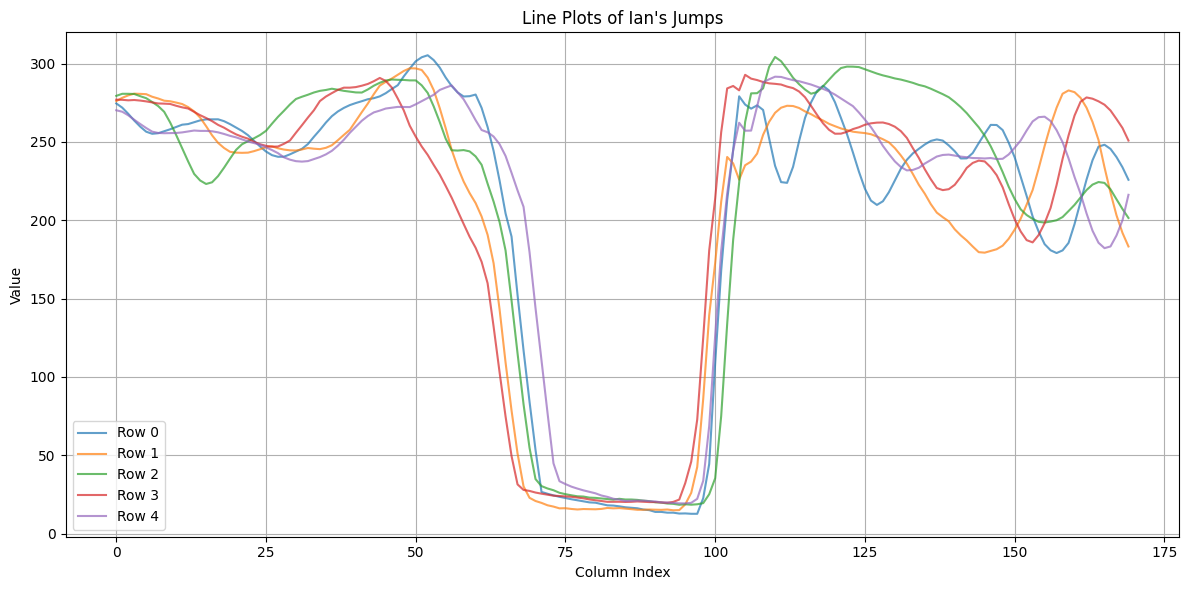

In [13]:
# Plot each row as a line
plt.figure(figsize=(12, 6))
for i in range(len(connor.iloc[:, :170])):
    plt.plot(connor.iloc[:, :170].columns, connor.iloc[i, :170], alpha=0.7, label=f'Row {i}')

plt.title("Line Plots of Ian's Jumps")
plt.xlabel('Column Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()

In [14]:
matthew = pd.read_csv("Math_232_Data/data/MatthewRiley_filtered.csv")
matthew = matthew.iloc[:, 1:171]
matthew = matthew.drop(index = [2, 5, 7, 8])
matthew.columns = list(range(len(matthew.columns)))
matthew["label"] = "Matthew"
matthew.head()


,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
0,264.56,263.96,263.24,262.48,261.12,260.32,259.36,258.12,257.08,256.32,...,223.40,236.88,246.48,253.20,253.04,249.60,242.48,233.48,223.60,Matthew
1,259.80,261.24,262.84,264.52,265.80,266.12,267.64,268.56,269.60,270.04,...,178.12,171.64,178.44,194.48,212.48,231.04,247.12,255.40,257.88,Matthew
3,264.08,267.32,272.16,277.96,282.96,285.80,287.20,287.48,287.36,286.68,...,265.60,266.40,266.92,266.76,267.04,266.64,266.36,267.04,268.44,Matthew
4,258.12,252.56,246.68,240.40,234.68,229.12,224.28,220.04,217.52,216.40,...,264.12,265.00,265.36,265.92,266.60,266.96,267.40,267.76,267.88,Matthew
6,310.36,310.24,309.84,309.80,309.36,308.80,308.64,308.48,308.20,307.72,...,251.96,242.28,233.64,226.72,224.28,229.44,238.56,251.32,255.56,Matthew


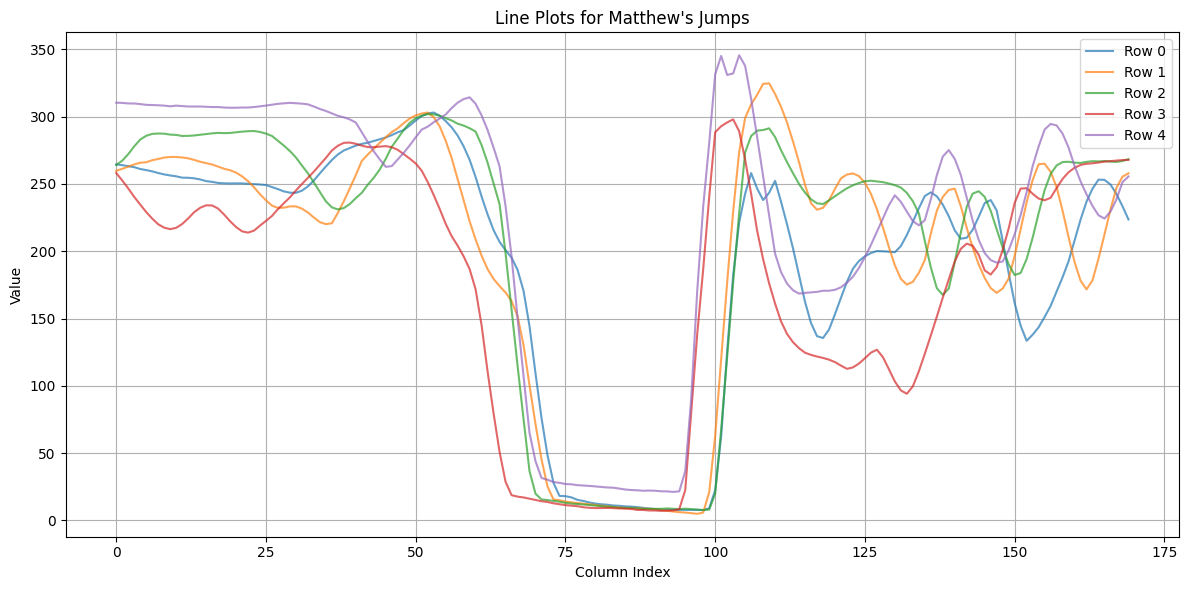

In [15]:
# Plot each row as a line
plt.figure(figsize=(12, 6))
for i in range(len(matthew.iloc[:, :170])):
    plt.plot(matthew.iloc[:, :170].columns, matthew.iloc[i, :170], alpha=0.7, label=f'Row {i}')

plt.title("Line Plots for Matthew's Jumps")
plt.xlabel('Column Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()

In [16]:
owen = pd.read_csv("Math_232_Data/data/Owen_filtered.csv")
owen = owen.iloc[:, 1:171]
owen = owen.drop(index = [0, 1, 2, 4, 9])
owen.columns = list(range(len(owen.columns)))
owen["label"] = "Owen"
owen.head()

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
3,254.64,256.76,258.92,259.88,259.84,258.92,257.00,252.24,246.52,239.64,...,277.60,288.48,291.32,283.56,268.04,247.88,226.24,204.36,195.68,Owen
5,159.60,166.88,181.08,197.56,211.64,226.84,240.32,247.88,252.48,256.48,...,268.00,270.92,266.80,256.72,237.88,218.76,200.68,185.16,174.68,Owen
6,167.32,174.20,190.08,210.24,232.48,255.04,268.00,270.92,266.80,256.72,...,269.76,269.76,270.16,269.84,269.44,269.16,269.28,269.44,269.84,Owen
7,233.40,231.44,230.56,229.28,228.88,228.48,228.92,229.52,231.16,232.32,...,217.72,214.96,212.24,210.48,209.04,208.80,209.20,208.96,207.84,Owen
8,246.88,246.04,247.68,257.84,267.24,274.36,274.92,273.36,270.60,267.04,...,210.52,210.76,211.20,211.76,211.64,211.36,211.92,213.28,214.36,Owen


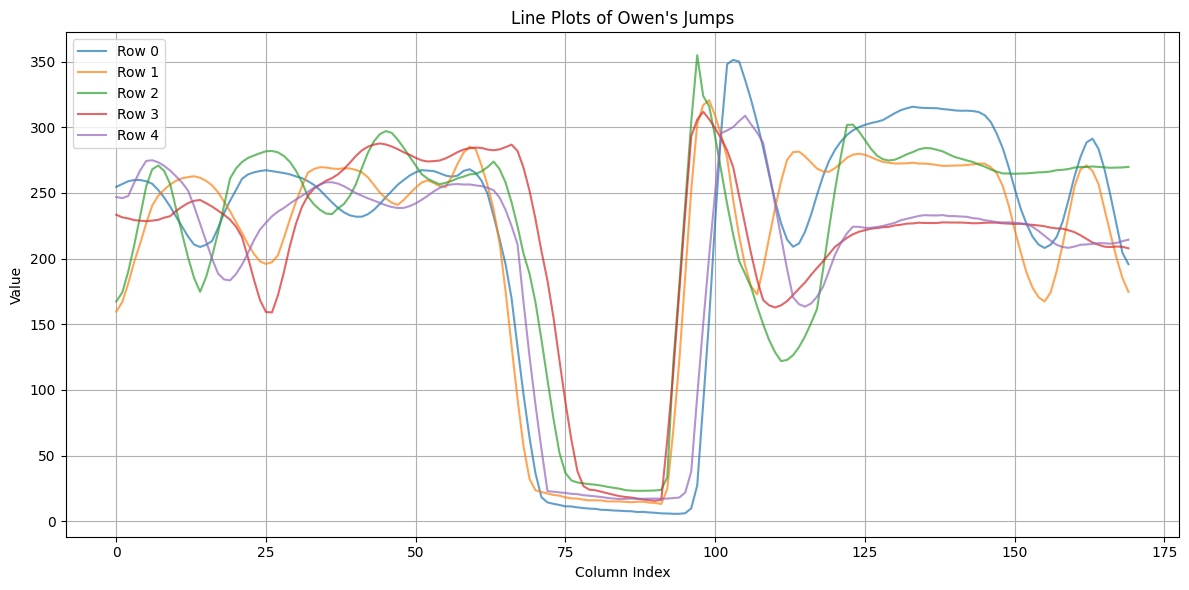

In [17]:
# Plot each row as a line
plt.figure(figsize=(12, 6))
for i in range(len(owen.iloc[:, :170])):
    plt.plot(owen.iloc[:, :170].columns, owen.iloc[i, :170], alpha=0.7, label=f'Row {i}')

plt.title("Line Plots of Owen's Jumps")
plt.xlabel('Column Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()

In [18]:
ian = pd.read_csv("Math_232_Data/data/IanLim_filtered.csv")
ian = ian.iloc[:, 1:171] # remove weird jumps
ian = ian.drop(index = [0, 1, 2, 3, 5, 6, 11, 12])
ian.columns = list(range(len(ian.columns)))
ian["label"] = "Ian"
ian.head()

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
4,314.72,314.72,314.40,314.24,313.76,313.48,313.52,313.96,314.72,315.64,...,319.64,319.80,319.40,318.48,318.04,317.32,316.00,314.52,313.88,Ian
7,294.48,294.96,295.32,295.04,295.00,295.12,294.84,294.92,295.12,294.80,...,250.00,255.48,261.04,266.04,270.12,272.92,275.44,276.96,277.28,Ian
8,310.56,310.08,309.52,308.48,306.20,303.04,297.96,290.96,282.20,272.56,...,284.04,283.12,282.56,281.88,281.84,281.76,281.80,282.48,282.76,Ian
9,306.64,307.64,308.08,308.96,309.80,310.28,310.12,310.52,310.40,310.56,...,306.32,304.12,301.40,299.04,296.04,293.68,292.48,291.76,292.68,Ian
10,296.04,293.68,292.48,291.76,292.68,294.80,296.92,299.00,300.88,302.00,...,243.36,254.40,264.28,270.72,273.12,272.68,269.76,264.16,252.96,Ian


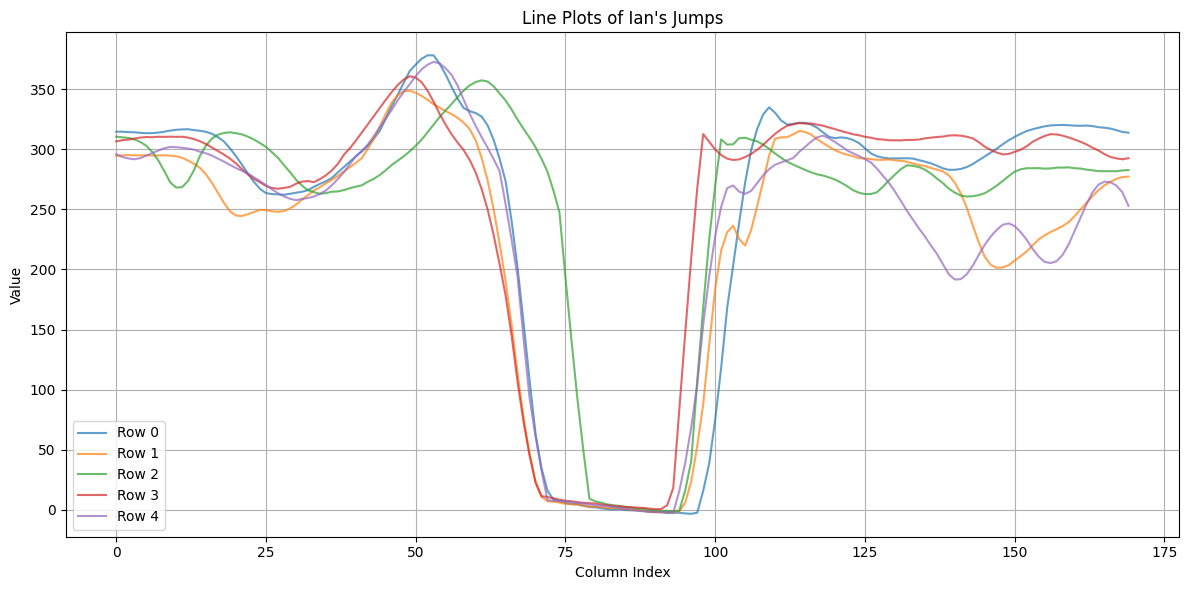

In [19]:
# Plot each row as a line
plt.figure(figsize=(12, 6))
for i in range(len(ian.iloc[:, :170])):
    plt.plot(ian.iloc[:, :170].columns, ian.iloc[i, :170], alpha=0.7, label=f'Row {i}')

plt.title("Line Plots of Ian's Jumps")
plt.xlabel('Column Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()

In [20]:
joshua = pd.read_csv("Math_232_Data/data/JoshuaGao_filtered.csv")
joshua = joshua.iloc[:, 1:171] 
joshua = joshua.drop(index = [1, 2])
joshua.columns = list(range(len(joshua.columns)))
joshua["label"] = "Joshua"
joshua.head()

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
0,233.84,233.44,233.36,233.72,234.28,235.04,235.68,234.88,232.56,229.00,...,182.08,189.48,196.12,200.16,202.04,201.60,199.80,196.56,193.12,Joshua
3,221.56,222.16,222.56,223.04,223.88,224.56,223.80,222.88,221.12,218.36,...,202.12,200.04,197.28,195.36,192.52,188.72,185.32,182.64,179.56,Joshua
4,239.96,240.28,240.80,240.84,240.76,239.92,238.60,236.28,233.00,228.72,...,214.72,214.44,214.80,214.88,215.48,215.24,215.44,215.32,214.52,Joshua
5,218.32,217.92,217.28,216.24,215.36,214.84,215.32,216.80,218.88,221.40,...,198.32,198.04,197.68,196.88,196.76,196.24,196.60,196.92,197.64,Joshua
6,265.56,265.52,265.96,265.52,264.32,262.96,261.56,259.44,256.48,252.96,...,219.20,212.56,204.60,195.92,188.68,182.08,177.28,176.28,177.40,Joshua


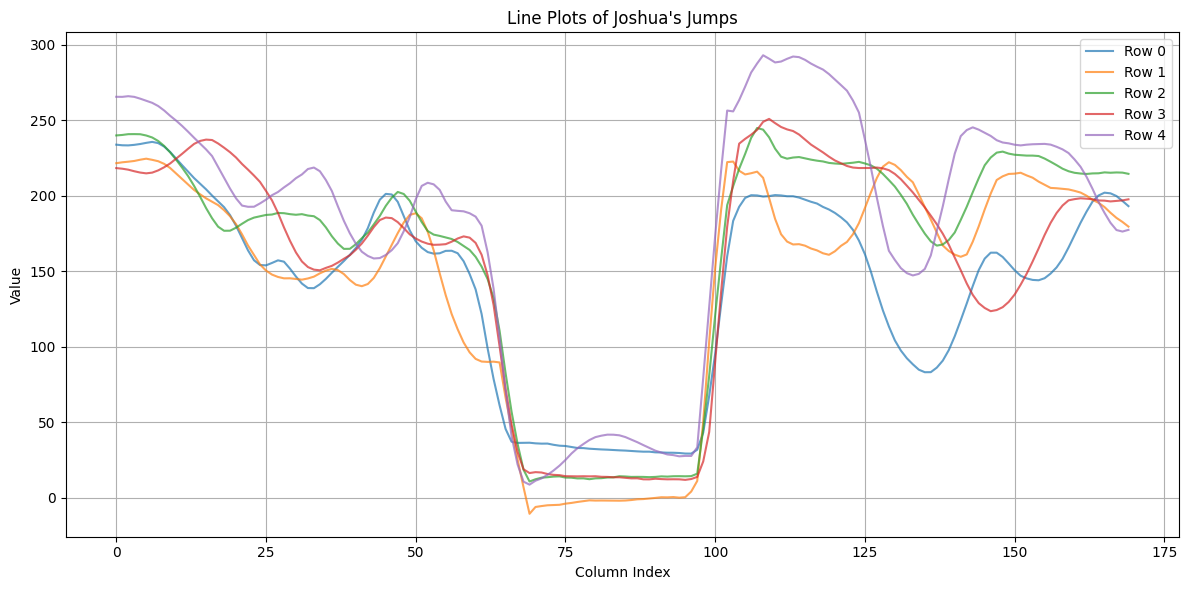

In [21]:
# Plot each row as a line
plt.figure(figsize=(12, 6))
for i in range(len(joshua.iloc[:, :170])):
    plt.plot(joshua.iloc[:, :170].columns, joshua.iloc[i, :170], alpha=0.7, label=f'Row {i}')

plt.title("Line Plots of Joshua's Jumps")
plt.xlabel('Column Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()

In [22]:
skylar = pd.read_csv("Math_232_Data/data/SkylarWang_filtered.csv")
skylar = skylar.iloc[:, 1:171] #
skylar = skylar.drop(index = [0, 1, 2, 4])
skylar.columns = list(range(len(skylar.columns)))
skylar["label"] = "Skylar"
skylar.head()

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
3,186.92,204.12,220.20,228.68,230.64,222.56,206.16,189.24,176.24,166.96,...,276.64,266.76,247.20,226.84,207.16,189.24,173.60,166.92,161.68,Skylar
5,212.56,216.28,220.84,225.20,229.32,232.16,233.72,234.28,234.64,229.24,...,202.52,195.44,189.88,185.16,181.08,178.00,175.56,172.84,170.56,Skylar
6,184.20,176.72,169.52,164.36,160.16,156.48,152.76,149.40,146.72,144.72,...,219.24,214.96,212.68,211.52,210.48,209.68,208.84,208.48,208.52,Skylar
7,223.00,215.56,204.60,191.44,178.52,166.00,155.68,147.16,140.72,136.48,...,215.16,215.48,213.92,210.76,206.12,201.64,197.00,192.16,187.20,Skylar
8,278.40,277.72,277.28,275.72,274.92,273.84,273.32,272.84,272.36,270.68,...,240.24,237.04,231.24,223.88,215.92,207.20,198.28,192.96,189.60,Skylar


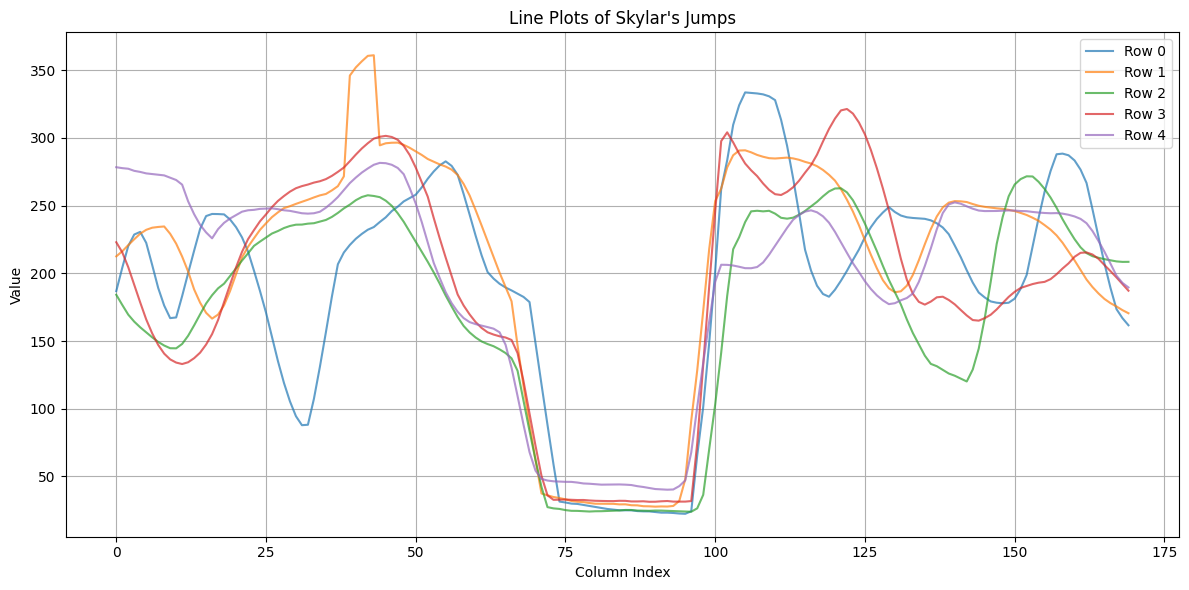

In [23]:
# Plot each row as a line
plt.figure(figsize=(12, 6))
for i in range(len(skylar.iloc[:, :170])):
    plt.plot(skylar.iloc[:, :170].columns, skylar.iloc[i, :170], alpha=0.7, label=f'Row {i}')

plt.title("Line Plots of Skylar's Jumps")
plt.xlabel('Column Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()

In [24]:
jake = pd.read_csv("Math_232_Data/data/Jake_filtered.csv")
jake = jake.iloc[:, 1:171]
# jake = jake.drop(index = [0, 1, 2, 4])
jake.columns = list(range(len(jake.columns)))
jake["label"] = "Jake"
jake.head()

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
0,279.12,286.44,299.00,313.36,329.20,344.36,344.84,345.84,347.52,349.44,...,311.20,321.72,328.44,329.92,329.80,328.84,326.64,323.20,317.60,Jake
1,349.00,350.60,351.56,352.12,352.20,351.24,350.40,349.84,349.60,349.48,...,288.52,301.96,310.00,316.88,321.48,324.92,327.04,328.64,329.92,Jake
2,285.28,263.00,238.88,220.60,206.32,197.96,193.64,193.72,196.96,203.36,...,281.44,283.60,285.52,286.96,288.72,290.16,291.56,292.56,293.48,Jake
3,305.16,307.84,309.60,310.80,311.44,312.56,313.24,313.80,314.40,314.24,...,290.76,289.32,289.24,289.28,290.44,292.64,295.00,296.12,297.32,Jake
4,345.16,352.68,358.56,361.60,363.76,363.48,364.08,363.32,361.04,353.84,...,300.28,302.32,302.32,302.32,301.40,300.60,300.00,300.96,302.40,Jake


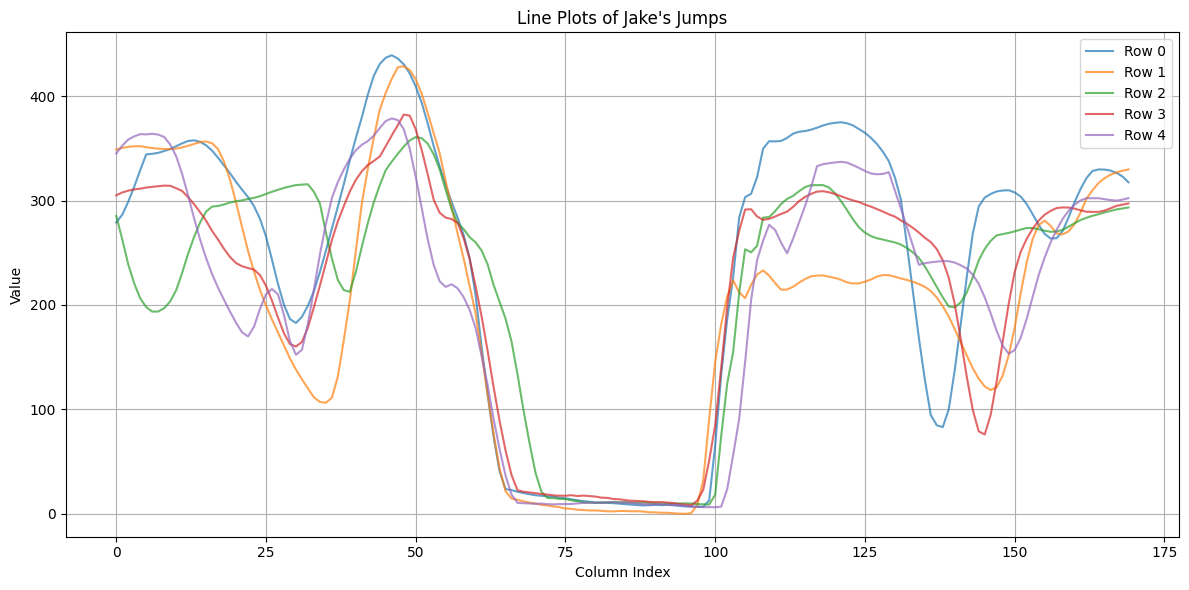

In [25]:
# Plot each row as a line
plt.figure(figsize=(12, 6))
for i in range(len(jake.iloc[:, :170])):
    plt.plot(jake.iloc[:, :170].columns, jake.iloc[i, :170], alpha=0.7, label=f'Row {i}')

plt.title("Line Plots of Jake's Jumps")
plt.xlabel('Column Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()

In [26]:
annie = pd.read_csv("Math_232_Data/data/AnnieGu_filtered.csv")
annie = annie.iloc[:, 1:171]
annie = annie.drop(index = [1, 3, 4])
annie.columns = list(range(len(annie.columns)))
annie["label"] = "Annie"
annie.head()

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
0,174.08,184.44,201.08,223.52,240.28,257.84,274.32,287.16,293.88,296.48,...,206.68,221.92,239.80,258.68,273.24,280.84,285.56,286.64,282.56,Annie
2,301.68,304.40,302.44,297.56,289.68,280.56,275.68,274.68,278.96,287.56,...,244.52,254.44,263.40,269.24,270.84,267.88,262.12,250.40,239.12,Annie
5,278.96,293.24,301.44,305.68,308.12,309.76,310.96,311.68,312.44,312.72,...,255.00,239.76,225.16,212.20,201.84,194.96,192.76,199.44,212.00,Annie
6,115.52,122.32,130.36,139.64,150.60,163.40,179.92,203.64,238.48,271.60,...,310.08,310.96,311.32,311.04,310.64,310.40,310.16,310.32,310.84,Annie
7,276.32,271.84,267.52,262.84,256.64,248.08,238.36,227.20,215.16,204.20,...,336.24,337.04,337.92,338.72,339.88,340.68,341.00,340.92,339.60,Annie


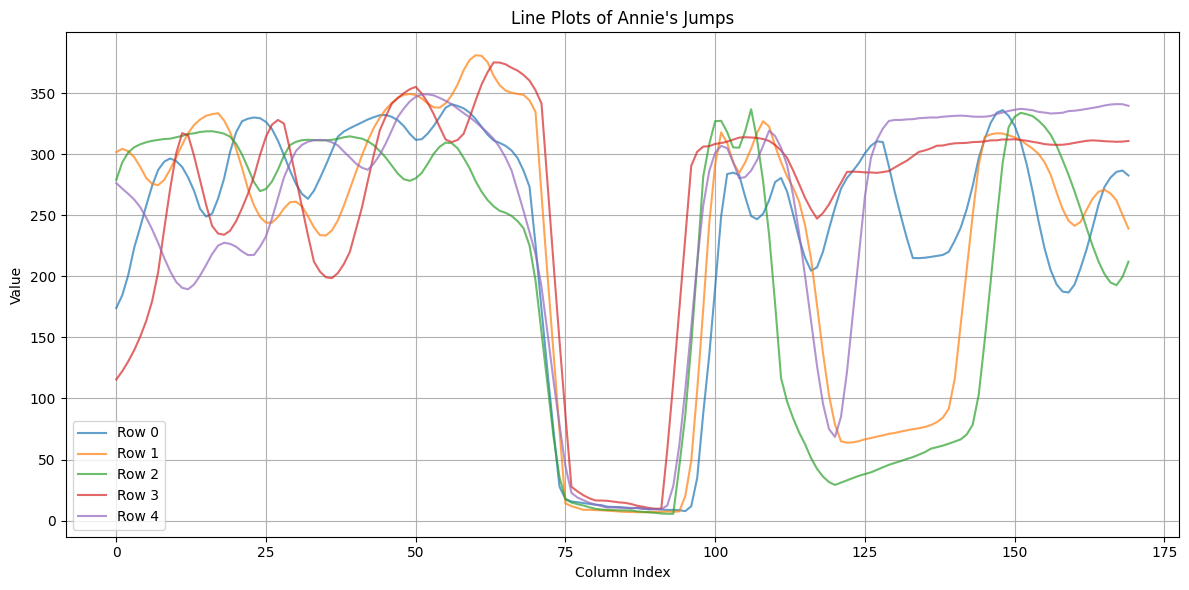

In [27]:
# Plot each row as a line
plt.figure(figsize=(12, 6))
for i in range(len(annie.iloc[:, :170])):
    plt.plot(annie.iloc[:, :170].columns, annie.iloc[i, :170], alpha=0.7, label=f'Row {i}')

plt.title("Line Plots of Annie's Jumps")
plt.xlabel('Column Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()

In [28]:
emma = pd.read_csv("Math_232_Data/data/Emma_filtered.csv")
emma = emma.iloc[:, 1:171]
emma = emma.drop(index = [1, 5])
emma.columns = list(range(len(emma.columns)))
emma["label"] = "Emma"
emma.head()

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
0,204.76,197.04,188.32,179.20,170.32,162.52,155.88,150.00,146.40,144.80,...,74.20,72.52,73.80,78.72,84.24,90.24,96.04,100.76,104.68,Emma
2,179.04,174.32,169.60,165.24,163.64,164.00,166.88,172.52,178.48,183.00,...,137.28,147.56,161.48,175.08,189.76,203.24,211.88,215.96,214.96,Emma
3,232.08,234.40,236.40,237.96,237.96,237.24,230.96,223.60,215.00,206.60,...,80.08,80.16,81.44,83.32,86.16,97.32,113.20,131.96,151.40,Emma
4,156.28,166.36,178.72,189.64,200.28,210.12,218.84,226.36,223.32,217.32,...,155.52,169.52,185.68,201.28,214.16,209.52,199.40,185.64,170.96,Emma
6,177.60,177.28,177.52,177.28,176.84,177.48,178.60,179.56,181.52,183.64,...,168.04,168.16,169.20,169.96,170.56,170.40,169.60,167.84,163.36,Emma


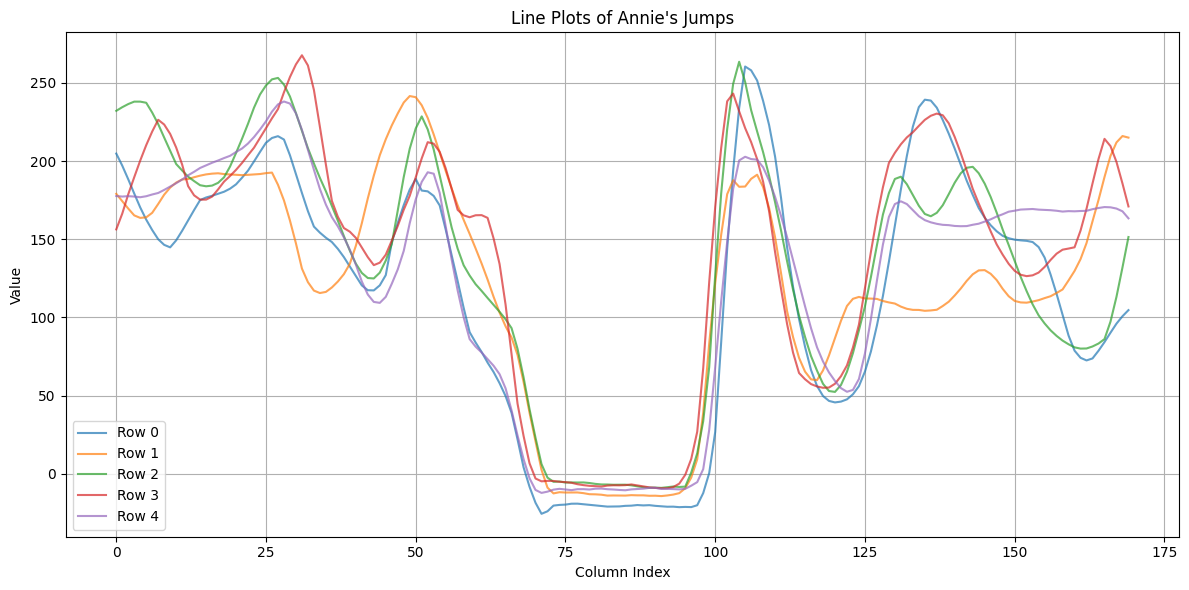

In [29]:
# Plot each row as a line
plt.figure(figsize=(12, 6))
for i in range(len(emma.iloc[:, :170])):
    plt.plot(emma.iloc[:, :170].columns, emma.iloc[i, :170], alpha=0.7, label=f'Row {i}')

plt.title("Line Plots of Annie's Jumps")
plt.xlabel('Column Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()

In [30]:
chu = pd.read_csv("Math_232_Data/data/Chu_filtered.csv")
chu = chu.iloc[:, 1:171]
chu = chu.drop(index = [0, 6])
chu.columns = list(range(len(chu.columns)))
chu["label"] = "Chu"
chu.head()

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
1,217.00,229.36,245.32,255.20,261.96,264.40,263.20,259.84,258.28,257.76,...,289.44,297.48,304.76,311.56,315.96,317.44,317.16,309.88,298.56,Chu
2,276.16,283.12,285.80,284.44,278.08,268.00,257.96,248.68,240.60,235.56,...,276.96,276.76,277.72,277.36,278.20,278.52,278.84,279.36,286.36,Chu
3,291.40,289.24,286.40,283.32,280.92,278.36,276.96,276.76,277.72,277.36,...,300.68,299.64,297.56,293.92,290.24,286.76,282.44,277.96,274.84,Chu
4,306.24,306.40,306.28,306.52,307.24,308.04,308.68,310.04,311.56,313.16,...,346.68,347.84,348.44,347.64,345.36,341.68,338.96,337.00,334.64,Chu
5,243.80,263.72,286.20,296.32,303.80,309.24,312.80,316.08,320.28,325.92,...,291.52,279.24,266.24,254.24,244.64,237.48,248.60,262.80,280.24,Chu


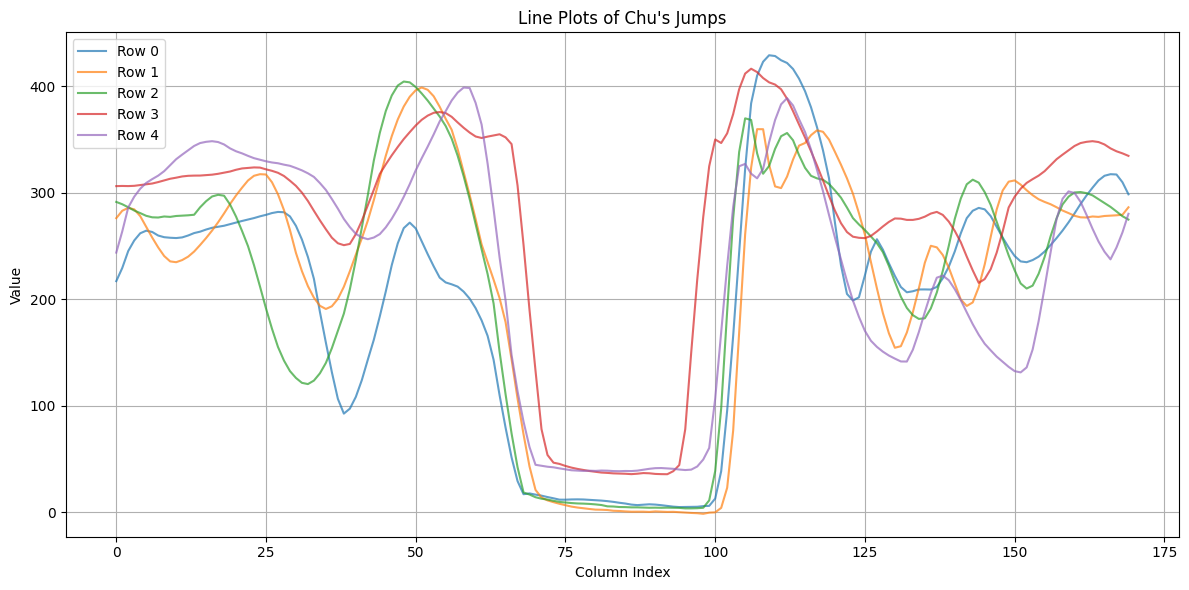

In [31]:
# Plot each row as a line
plt.figure(figsize=(12, 6))
for i in range(len(chu.iloc[:, :170])):
    plt.plot(chu.iloc[:, :170].columns, chu.iloc[i, :170], alpha=0.7, label=f'Row {i}')

plt.title("Line Plots of Chu's Jumps")
plt.xlabel('Column Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()

In [32]:
garrett = pd.read_csv("Math_232_Data/data/Garrett_filtered.csv")
garrett = garrett.iloc[:, 1:171]
# garret = garret.drop(index = [0, 6])
garrett.columns = list(range(len(garrett.columns)))
garrett["label"] = "Garrett"
garrett.head()

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
0,327.12,327.64,328.12,328.52,328.80,328.84,329.28,329.40,329.48,329.16,...,299.64,287.52,275.48,262.12,249.60,239.16,231.88,225.68,221.12,Garrett
1,298.40,297.28,295.96,294.68,294.40,294.16,294.20,294.72,295.60,296.40,...,254.52,275.52,299.44,317.60,328.64,334.52,334.60,329.28,318.80,Garrett
2,238.60,251.60,266.76,283.40,299.24,311.24,319.68,325.52,329.52,332.44,...,261.44,245.40,237.24,245.36,267.64,291.40,314.12,331.56,337.48,Garrett


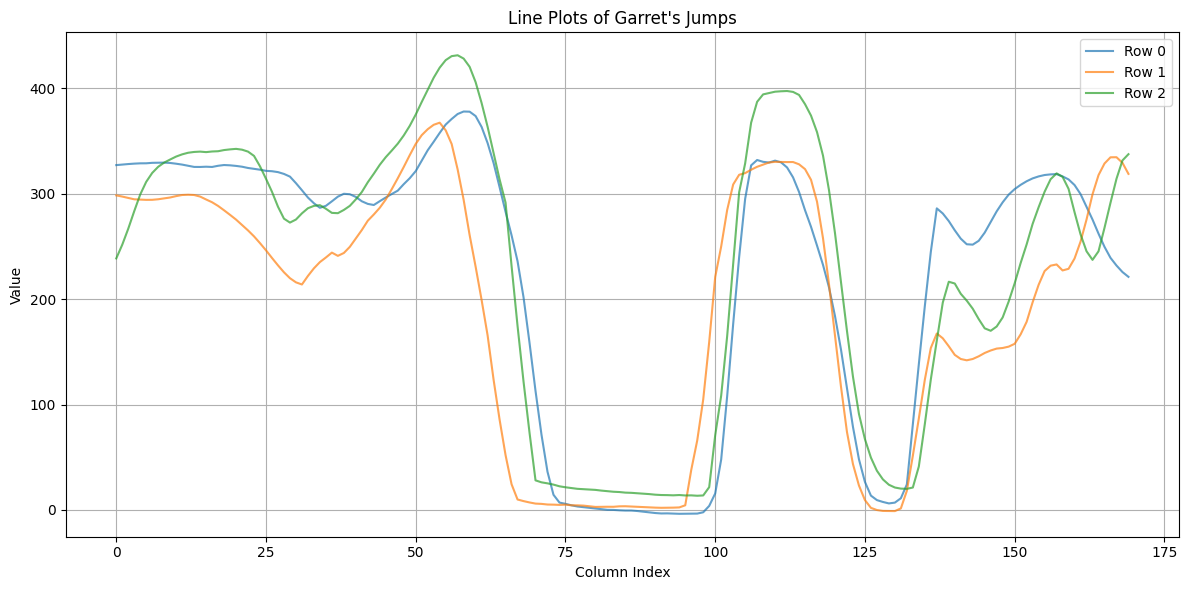

In [33]:
# Plot each row as a line
plt.figure(figsize=(12, 6))
for i in range(len(garrett.iloc[:, :170])):
    plt.plot(garrett.iloc[:, :170].columns, garrett.iloc[i, :170], alpha=0.7, label=f'Row {i}')

plt.title("Line Plots of Garret's Jumps")
plt.xlabel('Column Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()

In [34]:
sylvie = pd.read_csv("Math_232_Data/data/Sylvie_filtered.csv")
sylvie = sylvie.iloc[:, 1:171]
sylvie = sylvie.drop(index = [2])
sylvie.columns = list(range(len(sylvie.columns)))
sylvie["label"] = "Sylvie"
sylvie.head()

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
0,232.56,231.20,230.44,229.92,228.84,227.72,227.24,226.20,225.52,224.48,...,258.04,259.12,260.56,260.88,261.16,261.20,260.84,260.64,261.20,Sylvie
1,210.12,212.44,216.16,220.84,225.40,230.04,234.80,238.44,240.76,242.24,...,207.32,207.56,207.72,207.84,207.68,207.32,207.36,207.56,207.36,Sylvie
3,248.80,249.48,250.24,250.96,251.48,252.28,252.48,252.64,252.52,251.76,...,241.56,250.92,255.92,258.16,259.32,259.56,260.08,260.36,260.92,Sylvie
4,270.16,270.52,270.80,270.80,271.04,270.76,270.40,269.84,268.28,267.00,...,252.88,254.48,255.24,256.08,258.16,260.28,261.48,263.04,263.84,Sylvie
5,249.12,251.32,252.88,254.48,255.24,256.08,258.16,260.28,261.48,263.04,...,199.16,199.96,202.28,203.92,205.92,208.48,211.44,212.72,214.60,Sylvie


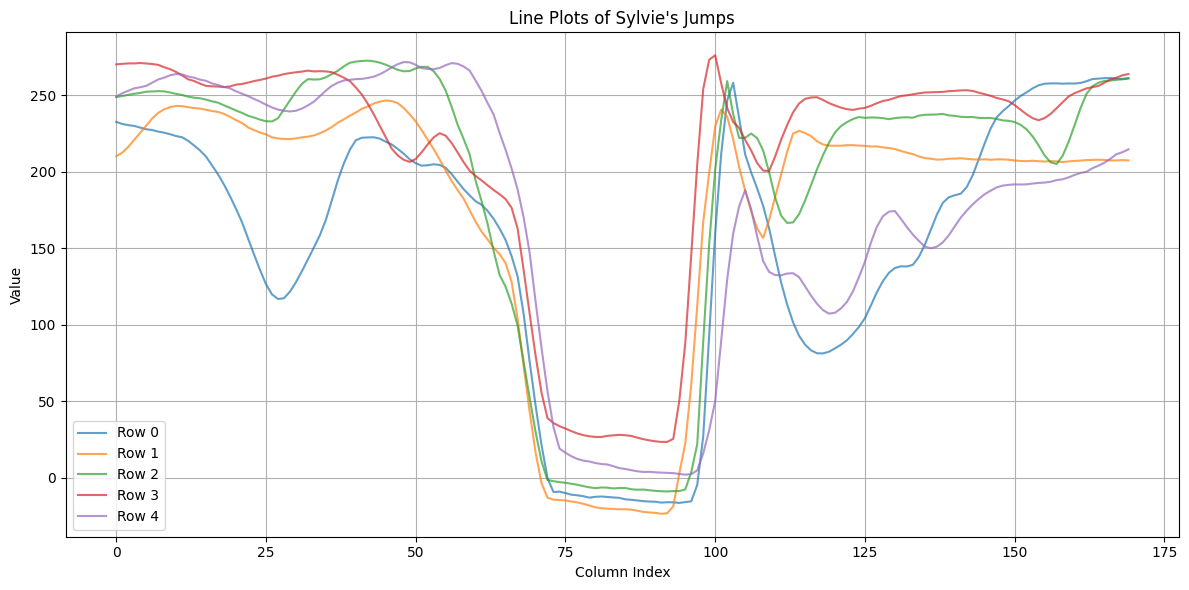

In [35]:
# Plot each row as a line
plt.figure(figsize=(12, 6))
for i in range(len(sylvie.iloc[:, :170])):
    plt.plot(sylvie.iloc[:, :170].columns, sylvie.iloc[i, :170], alpha=0.7, label=f'Row {i}')

plt.title("Line Plots of Sylvie's Jumps")
plt.xlabel('Column Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()

In [36]:
# concatenate
merged_df = pd.concat([df, connor, matthew, owen, ian, joshua, skylar, jake, annie, emma, chu], ignore_index = True)

In [37]:
merged_df.isna().sum().sum()

np.int64(0)

In [38]:
merged_df.shape

(60, 171)

In [39]:
merged_df.head()

,0,1,2,3,4,5,6,7,8,9,...,161,162,163,164,165,166,167,168,169,label
0,159.40,159.28,159.08,158.84,158.60,157.96,157.92,157.48,157.32,157.00,...,126.60,125.52,125.36,125.60,126.20,127.00,127.92,127.96,126.60,Colin
1,181.40,181.12,180.68,180.32,180.40,180.60,180.80,181.32,181.64,181.76,...,167.60,158.68,150.40,141.88,133.44,123.56,117.04,112.08,110.00,Colin
2,145.64,146.88,148.68,150.12,151.84,153.08,154.24,154.76,155.44,155.84,...,139.60,139.44,139.64,139.52,140.08,140.24,140.64,140.40,140.00,Colin
3,143.08,147.24,151.92,155.80,157.80,158.40,159.28,160.48,161.64,162.72,...,108.64,115.08,122.24,129.08,134.92,139.60,142.24,142.84,142.40,Colin
4,165.48,166.40,167.68,169.04,169.88,170.20,170.76,171.28,171.92,172.12,...,143.04,142.96,142.88,141.96,140.28,134.56,128.04,120.32,111.76,Colin


# Perform PCA

In [40]:
data = merged_df.iloc[:, :170]

X = data.values

X_centered = X - np.mean(X, axis=0, keepdims=True)
X_std      = X_centered / np.std(X_centered, axis=0, ddof=1)
B = X_std

U, s, Vt = np.linalg.svd(B, full_matrices=False)

print(f"U shape: {U.shape}")
print(f"s shape: {s.shape}")
print(f"Vt shape: {Vt.shape}")

U shape: (60, 60)
s shape: (60,)
Vt shape: (60, 170)


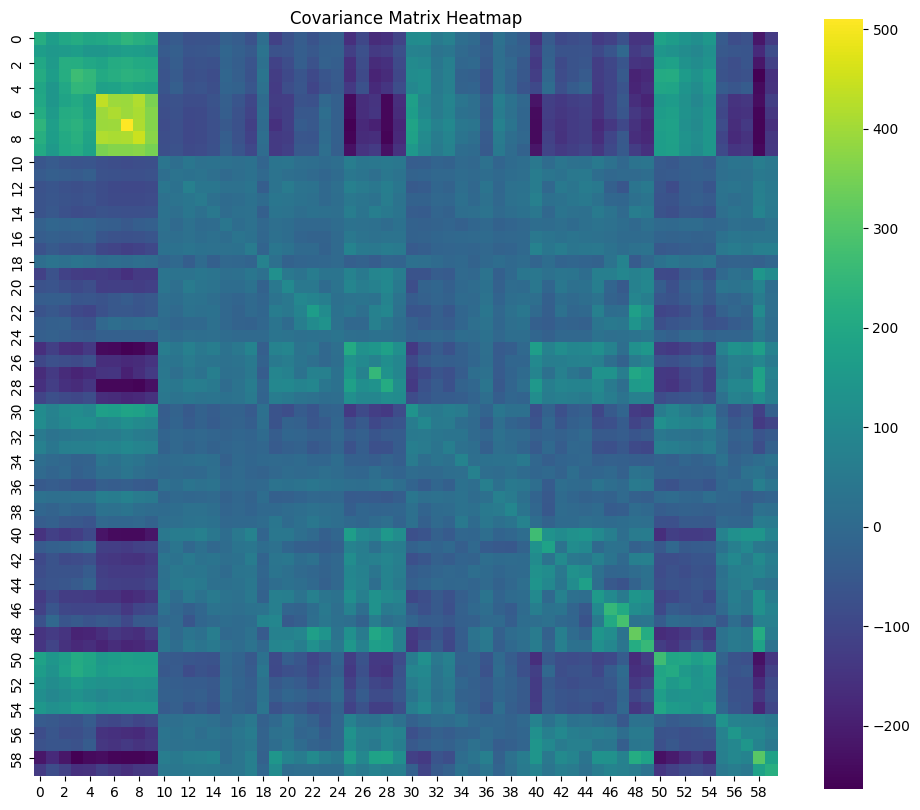

Shape of covariance matrix: (60, 60)

Maximum value: 509.78476368107266
Minimum value: -263.97128625260973
Mean value: 3.868510450249434e-16


In [41]:
covariance_matrix = B @ B.T

plt.figure(figsize=(12, 10))
sns.heatmap(covariance_matrix, 
            cmap='viridis',
            square=True)
plt.title('Covariance Matrix Heatmap')
plt.show()

# Print some basic statistics about the covariance matrix
print("Shape of covariance matrix:", covariance_matrix.shape)
print("\nMaximum value:", np.max(covariance_matrix))
print("Minimum value:", np.min(covariance_matrix))
print("Mean value:", np.mean(covariance_matrix))

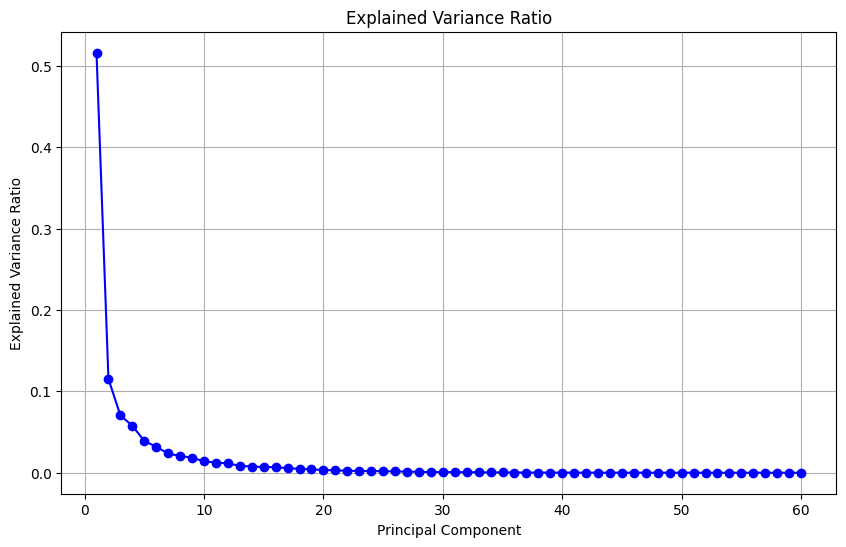

In [42]:
# Calculate the principal components (PCs)
# The columns of Vt are the right singular vectors (eigenvectors of B^T B)
PCs = Vt.T  # This gives us the principal components

# Calculate the scores (projections of the data onto the PCs)
scores = B @ PCs

# Calculate the explained variance ratio
total_var = np.sum(s**2)
explained_var_ratio = (s**2) / total_var

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var_ratio) + 1), explained_var_ratio, 'bo-')
plt.title('Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

In [43]:
# Print the cumulative explained variance
cumulative_var = np.cumsum(explained_var_ratio)
print("Cumulative explained variance ratio:")
for i, var in enumerate(cumulative_var):
    print(f"PC{i+1}: {var:.4f}")

Cumulative explained variance ratio:
PC1: 0.5162
PC2: 0.6314
PC3: 0.7019
PC4: 0.7596
PC5: 0.7987
PC6: 0.8306
PC7: 0.8542
PC8: 0.8747
PC9: 0.8932
PC10: 0.9071
PC11: 0.9196
PC12: 0.9310
PC13: 0.9396
PC14: 0.9471
PC15: 0.9542
PC16: 0.9609
PC17: 0.9665
PC18: 0.9713
PC19: 0.9755
PC20: 0.9788
PC21: 0.9817
PC22: 0.9841
PC23: 0.9863
PC24: 0.9883
PC25: 0.9902
PC26: 0.9918
PC27: 0.9932
PC28: 0.9943
PC29: 0.9952
PC30: 0.9959
PC31: 0.9966
PC32: 0.9972
PC33: 0.9978
PC34: 0.9982
PC35: 0.9985
PC36: 0.9988
PC37: 0.9990
PC38: 0.9992
PC39: 0.9993
PC40: 0.9994
PC41: 0.9996
PC42: 0.9996
PC43: 0.9997
PC44: 0.9998
PC45: 0.9998
PC46: 0.9998
PC47: 0.9999
PC48: 0.9999
PC49: 0.9999
PC50: 0.9999
PC51: 1.0000
PC52: 1.0000
PC53: 1.0000
PC54: 1.0000
PC55: 1.0000
PC56: 1.0000
PC57: 1.0000
PC58: 1.0000
PC59: 1.0000
PC60: 1.0000


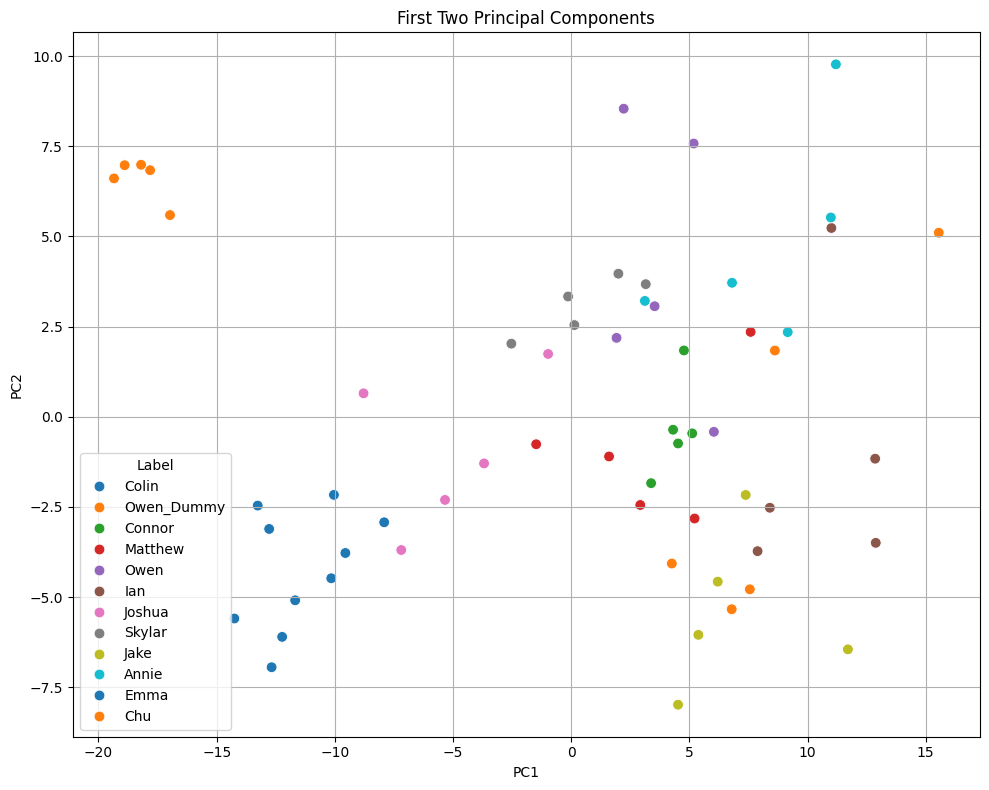

In [44]:
# Plot the first two principal components
labels = merged_df["label"]
pca_df = pd.DataFrame({
    'PC1': scores[:, 0],
    'PC2': scores[:, 1],
    'Label': labels  # categorical labels, e.g., 'annie', 'bob'
})

# Plot with seaborn: hue assigns color by label
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Label', palette='tab10', s=60)

plt.title('First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Label')
plt.grid(True)
plt.tight_layout()
plt.show()

Look at the loadings

In [47]:
# 1. turn scores into a DataFrame and name the columns PC1, PC2, …
pc_cols = [f"PC{i+1}" for i in range(scores.shape[1])]
full_pca_df = pd.DataFrame(scores, columns=pc_cols)

# 2. add your labels
full_pca_df["label"] = labels

# 3. (optional) reset the index, drop old index if you don’t want it in your CSV
full_pca_df.reset_index(drop=True, inplace=True)

# 4. write out
full_pca_df.to_csv("full_pca_df.csv", index=False)

In [46]:
loadings = pd.DataFrame(Vt.T)

# ——— Loop to pull out max index & value per column ———
for col in loadings.columns:
    max_idx = loadings[col].idxmax()   # label of the row with the max
    max_val = loadings[col].max()      # the max value itself
    min_idx = loadings[col].idxmin()   # label of the row with the max
    min_val = loadings[col].min()      # the max value itself
    print(f"Column '{col}': max = {max_val} at index '{max_idx}'")
    print(f"Column '{col}': min = {min_val} at index '{min_idx}'")
    print("\n")

Column '0': max = 0.09626687116103787 at index '163'
Column '0': min = -0.041618586457424576 at index '79'


Column '1': max = 0.17214691865720227 at index '71'
Column '1': min = -0.07599048675642887 at index '0'


Column '2': max = 0.10713406931111255 at index '68'
Column '2': min = -0.16965570502136643 at index '122'


Column '3': max = 0.11939023483696733 at index '86'
Column '3': min = -0.2031061950041954 at index '134'


Column '4': max = 0.15619284818784798 at index '71'
Column '4': min = -0.17499154667521086 at index '31'


Column '5': max = 0.14804163306790585 at index '108'
Column '5': min = -0.2030100537892312 at index '98'


Column '6': max = 0.16399250844513827 at index '149'
Column '6': min = -0.14477540374111816 at index '76'


Column '7': max = 0.14714881174082925 at index '36'
Column '7': min = -0.12387671382378948 at index '103'


Column '8': max = 0.21423350563080346 at index '53'
Column '8': min = -0.16686563971630286 at index '152'


Column '9': max = 0.248297254880

# comparing highest three jumpers (colin, jake, connor) against three average people (skylar, annie, joshua)

U shape: (10, 10)
s shape: (10,)
Vt shape: (10, 170)


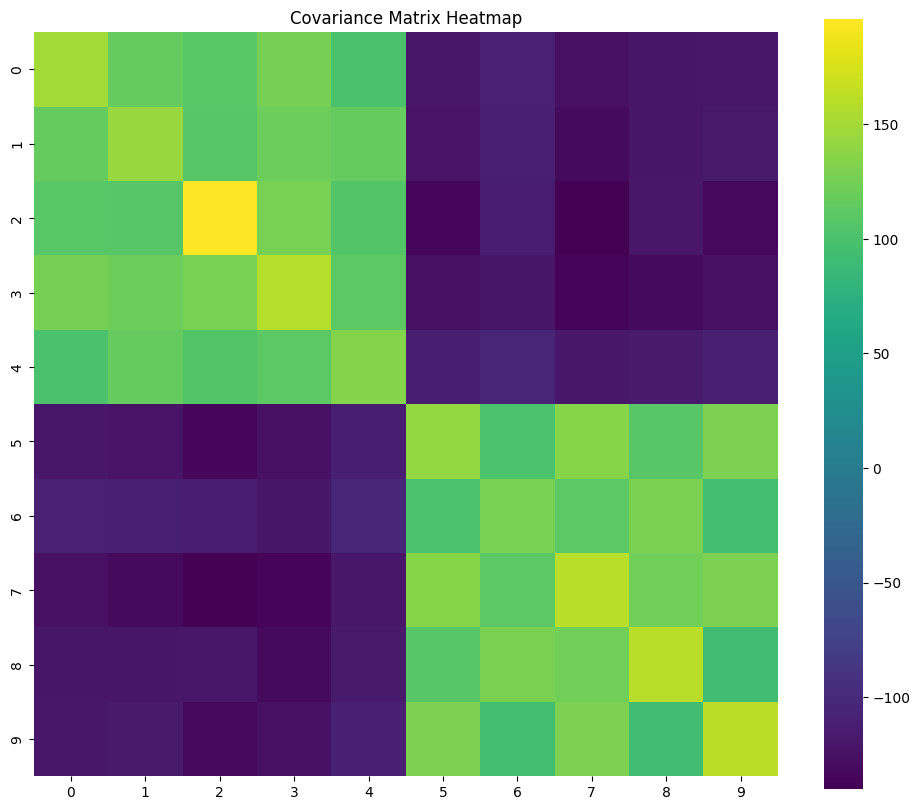

Shape of covariance matrix: (10, 10)

Maximum value: 195.90249945873384
Minimum value: -140.24405890753684
Mean value: -2.842170943040401e-16


In [91]:
compare = merged_df[merged_df["label"].isin(['Owen_Dummy', 'Connor'])]
X = compare.iloc[:, :170].values

X_centered = X - np.mean(X, axis=0, keepdims=True)
X_std      = X_centered / np.std(X_centered, axis=0, ddof=1)
B = X_std

U, s, Vt = np.linalg.svd(B, full_matrices=False)

print(f"U shape: {U.shape}")
print(f"s shape: {s.shape}")
print(f"Vt shape: {Vt.shape}")

covariance_matrix = B @ B.T

plt.figure(figsize=(12, 10))
sns.heatmap(covariance_matrix, 
            cmap='viridis',
            square=True)
plt.title('Covariance Matrix Heatmap')
plt.show()

# Print some basic statistics about the covariance matrix
print("Shape of covariance matrix:", covariance_matrix.shape)
print("\nMaximum value:", np.max(covariance_matrix))
print("Minimum value:", np.min(covariance_matrix))
print("Mean value:", np.mean(covariance_matrix))

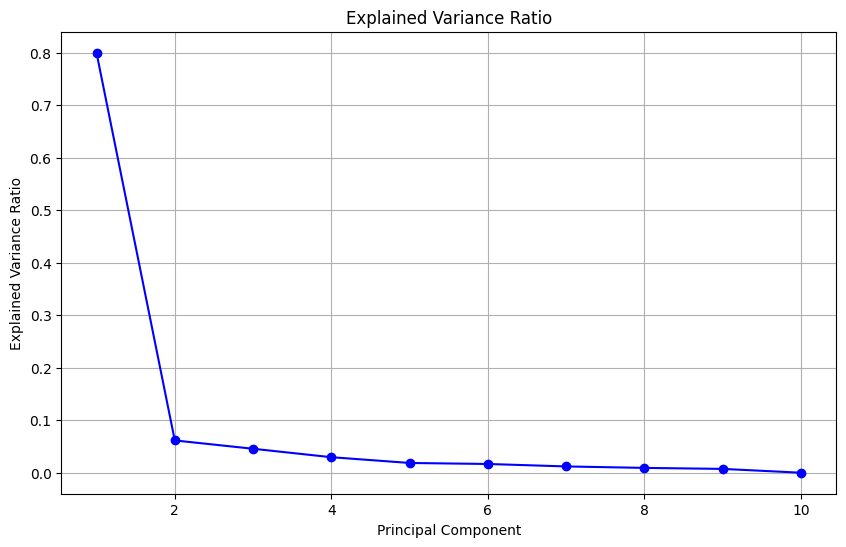

In [92]:
# Calculate the principal components (PCs)
# The columns of Vt are the right singular vectors (eigenvectors of B^T B)
PCs = Vt.T  # This gives us the principal components

# Calculate the scores (projections of the data onto the PCs)
scores = B @ PCs

# Calculate the explained variance ratio
total_var = np.sum(s**2)
explained_var_ratio = (s**2) / total_var

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var_ratio) + 1), explained_var_ratio, 'bo-')
plt.title('Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

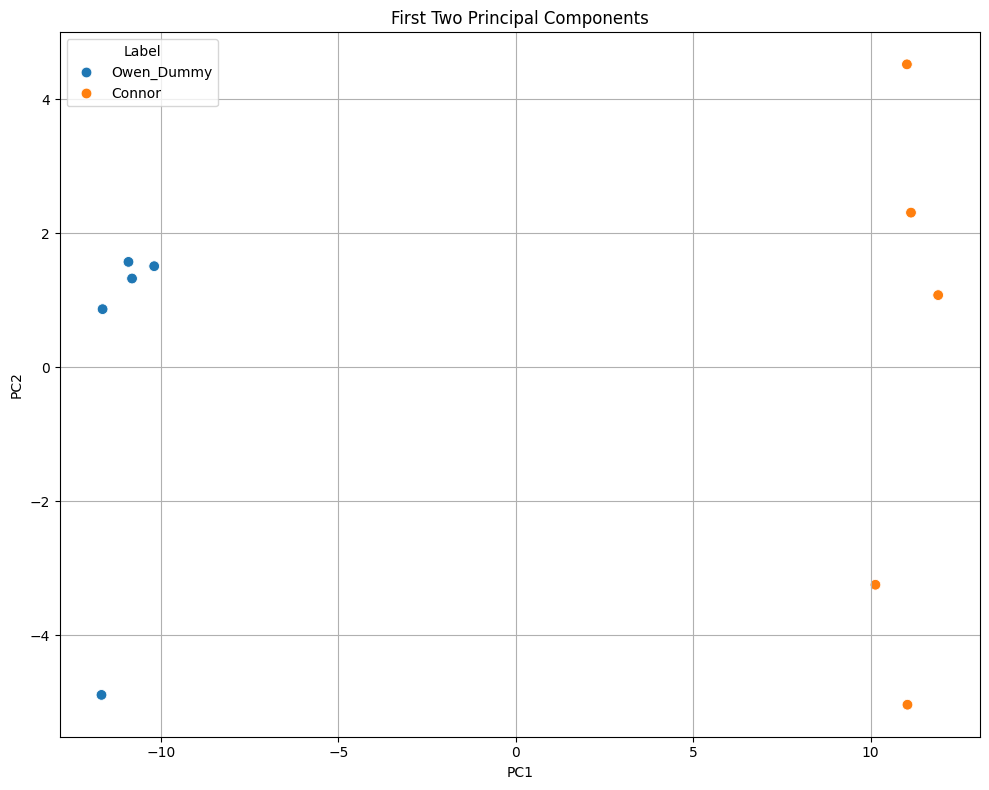

In [93]:
# Plot the first two principal components
labels = compare["label"]
pca_df = pd.DataFrame({
    'PC1': scores[:, 0],
    'PC2': scores[:, 1],
    'Label': labels  # categorical labels, e.g., 'annie', 'bob'
})

# Plot with seaborn: hue assigns color by label
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Label', palette='tab10', s=60)

plt.title('First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Label')
plt.grid(True)
plt.tight_layout()
plt.show()